Assignment 6 by Christopher Weiss

First Block are only the imports used in the rest of the assignment

In [2]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
from scipy import optimize


ModuleNotFoundError: No module named 'matplotlib'

Task 1: 

Visualization how the C-C, C-H, C-O and O-H bonds' potential energy differ from one another with different Distances(measured in Angstroms)

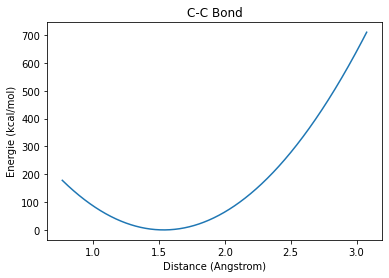

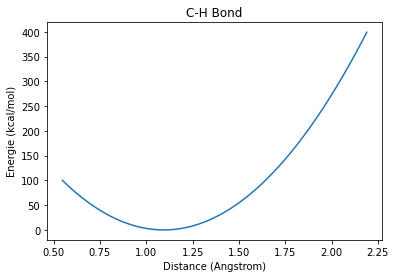

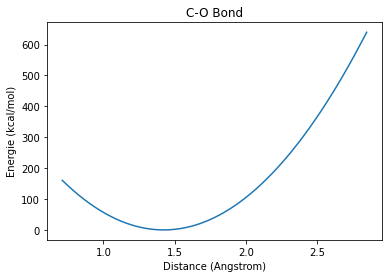

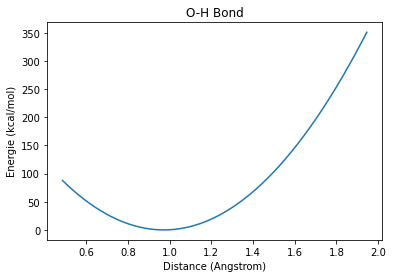

In [64]:

def energie_between_two_bonds(distance: float,harmonic_force: float,equilibrium: float) -> float:
    distance_minus_equilbrium=distance-equilibrium
    
    return harmonic_force*(distance_minus_equilbrium**2)-0.45*(distance_minus_equilbrium**3)
bond_type_parameters= pd.read_csv('parameters.csv')

for y in range(0,4,1):
    force_constant=bond_type_parameters['Force Constant'][y]
    equilibrium_distance=bond_type_parameters['Equilibrium Distance'][y]
    energie=[]
    distance=np.linspace(equilibrium_distance/2, equilibrium_distance*2, 1000)
    for x in distance:
        energie.append(energie_between_two_bonds(x,force_constant, equilibrium_distance))
    plt.figure()
    plt.plot(distance,energie)
    plt.title((bond_type_parameters['Bond Type'][y])+" Bond")
    plt.ylabel("Energie (kcal/mol)")
    plt.xlabel("Distance (Angstrom)")
    plt.show



Optimizing Bond distances:
    a)optimizing the initial bond distances of a given ethanol molecule
    (model_distances.csv contains the distances of the given ethanol molecule)
    
    b)reporting the optimized distances


In [79]:
distances=pd.read_csv('model_distances.csv')
df_merged= pd.merge(left=distances, right=bond_type_parameters, left_on='Bond Type', right_on='Bond Type')
optimized_distances=[]
for y in range(0,8,1):
    force_constant=df_merged['Force Constant'][y]
    equilibrium_distance=df_merged['Equilibrium Distance'][y]
    energie=energie_between_two_bonds(force_constant, equilibrium_distance, distance)
    optimized_distances=(optimize.minimize(fun=energie_between_two_bonds, x0=3.0,args=(force_constant, equilibrium_distance) ,method='Nelder-Mead',).x)
    print(f'The optimized distance for {df_merged["Atom Pair"][y]} is {optimized_distances} instead of {df_merged["Initial Distance"][y]}')


The optimized distance for C1-H1 is [1.0949707] instead of 1.01
The optimized distance for C1-H2 is [1.0949707] instead of 1.01
The optimized distance for C1-H3 is [1.0949707] instead of 1.01
The optimized distance for C2-H4 is [1.0949707] instead of 1.02
The optimized distance for C2-H5 is [1.0949707] instead of 1.02
The optimized distance for C1-C2 is [1.5380127] instead of 1.67
The optimized distance for C2-O1 is [1.42302246] instead of 1.41
The optimized distance for O1-H6 is [0.97302246] instead of 1.41
